# Week 6 Assignment: Prediction Shootout
## 雙事件內插比較 - 凱米颱風 vs 梅雨鋒面

# Week 6 Assignment: Prediction Shootout
## 雙事件內插比較 - 凱米颱風 vs 梅雨鋒面

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyproj import Transformer
import geopandas as gpd
from scipy.spatial import distance
from scipy.interpolate import NearestNDInterpolator
from sklearn.ensemble import RandomForestRegressor
from pykrige.ok import OrdinaryKriging
import rasterio
from rasterio.transform import from_origin
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib parameters
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('default')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Arial Unicode Ms']

In [3]:
# Data loading and filtering function
def load_and_filter_rainfall(csv_file, target_date):
    """
    Load rainfall data and filter for 花蓮縣+宜蘭縣 stations
    Remove -998 and 0 values
    """
    # Load data
    df = pd.read_csv(csv_file)
    
    # Filter for target date
    df['DateTime'] = pd.to_datetime(df['DateTime'])
    df_target = df[df['DateTime'].dt.date == pd.to_datetime(target_date).date()]
    
    # Filter for 花蓮縣 and 宜蘭縣
    target_counties = ['花蓮縣', '宜蘭縣']
    df_filtered = df_target[df_target['CountyName'].isin(target_counties)]
    
    # Remove -998 and 0 values from Past24hr (main rainfall column)
    df_clean = df_filtered[
        (df_filtered['Past24hr'] != -998) & 
        (df_filtered['Past24hr'] != 0) &
        (~df_filtered['Past24hr'].isna())
    ]
    
    print(f"Original stations: {len(df_target)}")
    print(f"Target county stations: {len(df_filtered)}")
    print(f"Clean stations (花蓮+宜蘭, no -998/0): {len(df_clean)}")
    
    return df_clean

# Coordinate conversion function
def convert_to_epsg3826(df):
    """
    Convert coordinates from EPSG:4326 to EPSG:3826
    """
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3826", always_xy=True)
    
    # Convert longitude, latitude to easting, northing
    easting, northing = transformer.transform(
        df['StationLongitude'].values, 
        df['StationLatitude'].values
    )
    
    df['Easting'] = easting
    df['Northing'] = northing
    
    return df

print("Functions defined!")

Functions defined!


=== Event 1: 凱米颱風 Data Loading ===
Original stations: 161407
Target county stations: 21023
Clean stations (花蓮+宜蘭, no -998/0): 21023

凱米颱風資料概況:
雨量範圍: 8.5 - 1031.0 mm
平均雨量: 190.8 mm
測站分布: {'花蓮縣': 12158, '宜蘭縣': 8865}


=== Event 2: 梅雨鋒面 Data Loading ===
Original stations: 159744
Target county stations: 20363
Clean stations (花蓮+宜蘭, no -998/0): 19520

梅雨鋒面資料概況:
雨量範圍: 0.5 - 149.5 mm
平均雨量: 14.9 mm
測站分布: {'花蓮縣': 11100, '宜蘭縣': 8420}
=== Loading Taiwan Main Island Town Boundaries ===
成功載入 352 個本島鄉鎮市區界線
分析範圍涵蓋 25 個目標縣市鄉鎮
本島涵蓋縣市: ['南投縣', '嘉義市', '嘉義縣', '基隆市', '宜蘭縣', '屏東縣', '彰化縣', '新北市', '新竹市', '新竹縣', '桃園市', '臺中市', '臺北市', '臺南市', '臺東縣', '花蓮縣', '苗栗縣', '雲林縣', '高雄市']
分析縣市: <StringArray>
['宜蘭縣', '花蓮縣']
Length: 2, dtype: str
圖表範圍: Easting 257700-357896, Northing 2526915-2794866
正在儲存測站位置圖（凱米颱風 vs 梅雨鋒面）到 outputs 目錄...
✅ 測站位置圖已儲存為 outputs/station_locations.png


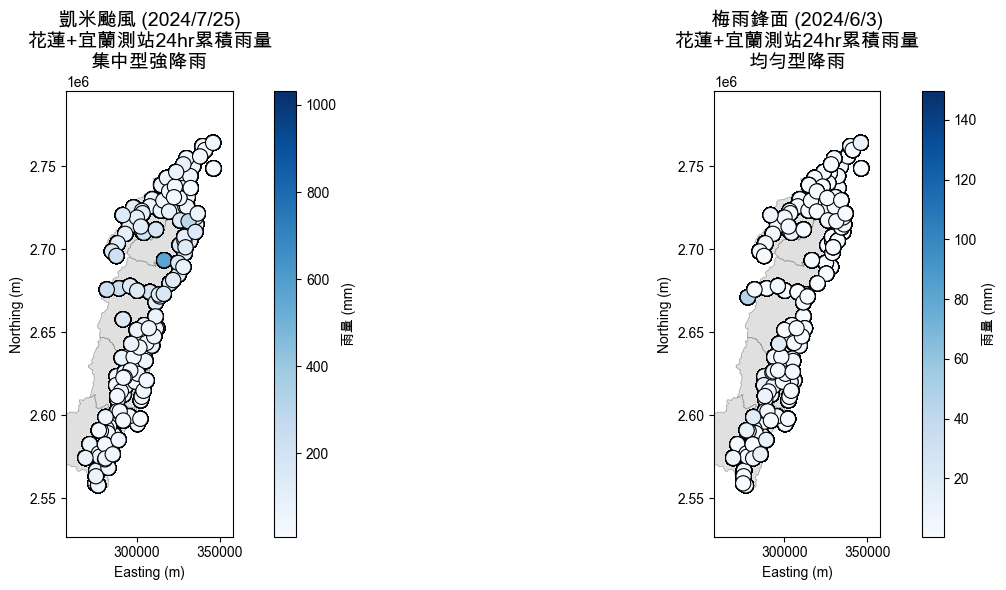

正在儲存雨量分布圖（凱米颱風 vs 梅雨鋒面）到 outputs 目錄...
✅ 雨量分布圖已儲存為 outputs/rainfall_distribution.png


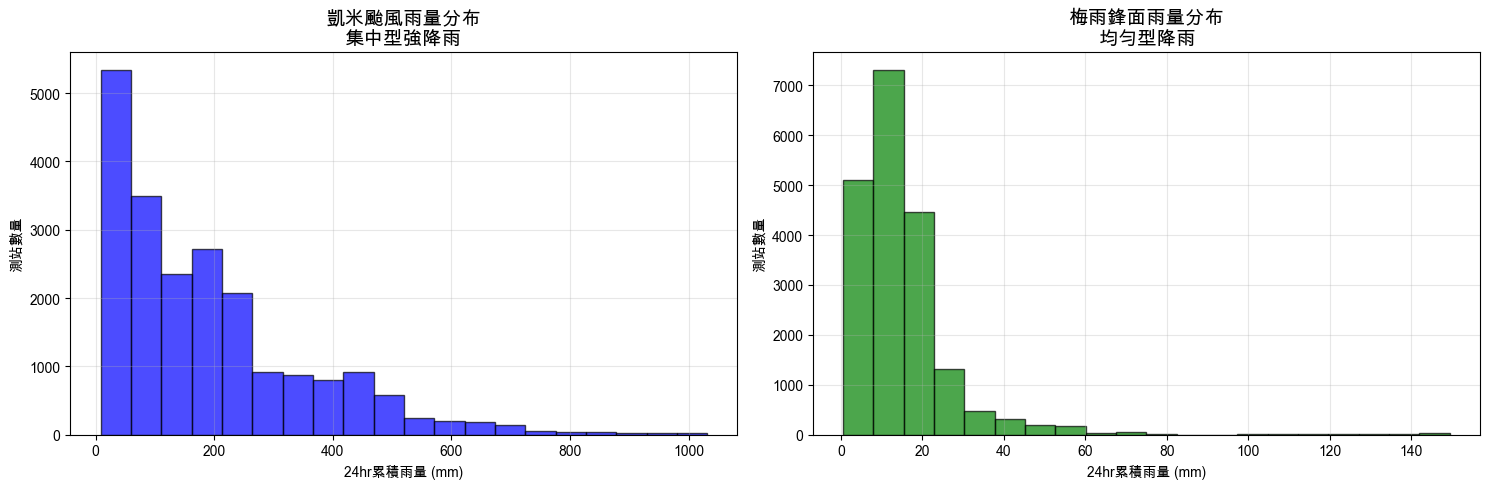

station_locations.png 檔案大小: 404,335 bytes
✅ station_locations.png 檔案大小正常，圖片應該有內容
rainfall_distribution.png 檔案大小: 136,069 bytes
✅ rainfall_distribution.png 檔案大小正常，圖片應該有內容

降雨特性比較分析

🌪️ 凱米颱風 (集中型強降雨):
   - 雨量範圍: 8.5 - 1031.0 mm
   - 平均雨量: 190.8 mm
   - 標準差: 165.7 mm
   - 變異係數: 0.87
   - 測站數量: 21023

🌧️ 梅雨鋒面 (均勻型降雨):
   - 雨量範圍: 0.5 - 149.5 mm
   - 平均雨量: 14.9 mm
   - 標準差: 13.7 mm
   - 變異係數: 0.92
   - 測站數量: 19520

📊 降雨特性對比:
   - 雨量變異性: 凱米颱風 (CV=0.87) vs 梅雨鋒面 (CV=0.92)
   → 梅雨鋒面變異性較高，符合均勻型降雨特徵
   - 最大雨量比: 6.9x
   - 平均雨量比: 12.8x


In [4]:
# Load Event 1: 凱米颱風 (2024/7/25) - 集中型強降雨
print("=== Event 1: 凱米颱風 Data Loading ===")
df_kaimi = load_and_filter_rainfall(
    '/Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/data/rain_20240725.csv', 
    '2024-07-25'
)
df_kaimi = convert_to_epsg3826(df_kaimi)

print(f"\n凱米颱風資料概況:")
print(f"雨量範圍: {df_kaimi['Past24hr'].min():.1f} - {df_kaimi['Past24hr'].max():.1f} mm")
print(f"平均雨量: {df_kaimi['Past24hr'].mean():.1f} mm")
print(f"測站分布: {df_kaimi['CountyName'].value_counts().to_dict()}")

print("\n" + "="*50 + "\n")

# Load Event 2: 梅雨鋒面 (2024/6/3) - 均勻型降雨
print("=== Event 2: 梅雨鋒面 Data Loading ===")
df_meiyu = load_and_filter_rainfall(
    '/Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/data/rain_20240603.csv', 
    '2024-06-03'
)
df_meiyu = convert_to_epsg3826(df_meiyu)

print(f"\n梅雨鋒面資料概況:")
print(f"雨量範圍: {df_meiyu['Past24hr'].min():.1f} - {df_meiyu['Past24hr'].max():.1f} mm")
print(f"平均雨量: {df_meiyu['Past24hr'].mean():.1f} mm")
print(f"測站分布: {df_meiyu['CountyName'].value_counts().to_dict()}")

# Load Taiwan town boundaries for basemap (main island only)
print("=== Loading Taiwan Main Island Town Boundaries ===")
town_shapefile = '/Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/data/鄉(鎮、市、區)界線1140318/TOWN_MOI_1140318.shp'
try:
    # Load town boundaries and convert to EPSG:3826
    towns_gdf = gpd.read_file(town_shapefile)
    towns_gdf = towns_gdf.to_crs('EPSG:3826')
    
    # Filter for main island counties (exclude outlying islands)
    # Main island counties that could have rainfall stations
    main_island_counties = [
        '新北市', '臺北市', '基隆市', '桃園市', '新竹市', '新竹縣', 
        '苗栗縣', '臺中市', '彰化縣', '南投縣', '雲林縣', '嘉義市', 
        '嘉義縣', '臺南市', '高雄市', '屏東縣', '宜蘭縣', '花蓮縣', '臺東縣'
    ]
    
    # Filter for main island counties
    towns_main_island = towns_gdf[towns_gdf['COUNTYNAME'].isin(main_island_counties)]
    
    # Further filter for our target counties (花蓮縣 and 宜蘭縣) for analysis
    target_counties = ['花蓮縣', '宜蘭縣']
    towns_filtered = towns_main_island[towns_main_island['COUNTYNAME'].isin(target_counties)]
    
    print(f"成功載入 {len(towns_main_island)} 個本島鄉鎮市區界線")
    print(f"分析範圍涵蓋 {len(towns_filtered)} 個目標縣市鄉鎮")
    print(f"本島涵蓋縣市: {sorted(towns_main_island['COUNTYNAME'].unique())}")
    print(f"分析縣市: {towns_filtered['COUNTYNAME'].unique()}")
    
except Exception as e:
    print(f"載入鄉鎮界線失敗: {e}")
    towns_filtered = None

# 計算兩個事件的範圍，用於置中顯示
all_stations = pd.concat([df_kaimi, df_meiyu])
x_min, x_max = all_stations['Easting'].min(), all_stations['Easting'].max()
y_min, y_max = all_stations['Northing'].min(), all_stations['Northing'].max()

# 計算適中的範圍（增加一些邊界）
x_buffer = (x_max - x_min) * 0.15  # 15% 邊界
y_buffer = (y_max - y_min) * 0.15  # 15% 邊界
x_center = (x_min + x_max) / 2
y_center = (y_min + y_max) / 2

# 設定置中的顯示範圍
plot_x_min = x_center - (x_max - x_min)/2 - x_buffer
plot_x_max = x_center + (x_max - x_min)/2 + x_buffer
plot_y_min = y_center - (y_max - y_min)/2 - y_buffer
plot_y_max = y_center + (y_max - y_min)/2 + y_buffer

print(f"圖表範圍: Easting {plot_x_min:.0f}-{plot_x_max:.0f}, Northing {plot_y_min:.0f}-{plot_y_max:.0f}")

# Visualize station locations and rainfall with town boundaries (centered)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Event 1: 凱米颱風 (集中型強降雨)
if towns_filtered is not None:
    # Plot town boundaries
    towns_filtered[towns_filtered['COUNTYNAME'] == '花蓮縣'].plot(
        ax=axes[0], facecolor='lightgray', edgecolor='gray', 
        linewidth=0.5, alpha=0.7, zorder=1
    )
    towns_filtered[towns_filtered['COUNTYNAME'] == '宜蘭縣'].plot(
        ax=axes[0], facecolor='lightgray', edgecolor='gray', 
        linewidth=0.5, alpha=0.7, zorder=1
    )

# Plot rainfall stations
scatter1 = axes[0].scatter(
    df_kaimi['Easting'], df_kaimi['Northing'], 
    c=df_kaimi['Past24hr'], s=120, cmap='Blues', 
    edgecolors='black', linewidth=0.8, zorder=2
)
axes[0].set_title('凱米颱風 (2024/7/25)\n花蓮+宜蘭測站24hr累積雨量\n集中型強降雨', fontsize=14)
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
axes[0].set_xlim(plot_x_min, plot_x_max)
axes[0].set_ylim(plot_y_min, plot_y_max)
plt.colorbar(scatter1, ax=axes[0], label='雨量 (mm)')

# Event 2: 梅雨鋒面 (均勻型降雨)
if towns_filtered is not None:
    # Plot town boundaries
    towns_filtered[towns_filtered['COUNTYNAME'] == '花蓮縣'].plot(
        ax=axes[1], facecolor='lightgray', edgecolor='gray', 
        linewidth=0.5, alpha=0.7, zorder=1
    )
    towns_filtered[towns_filtered['COUNTYNAME'] == '宜蘭縣'].plot(
        ax=axes[1], facecolor='lightgray', edgecolor='gray', 
        linewidth=0.5, alpha=0.7, zorder=1
    )

# Plot rainfall stations
scatter2 = axes[1].scatter(
    df_meiyu['Easting'], df_meiyu['Northing'], 
    c=df_meiyu['Past24hr'], s=120, cmap='Blues', 
    edgecolors='black', linewidth=0.8, zorder=2
)
axes[1].set_title('梅雨鋒面 (2024/6/3)\n花蓮+宜蘭測站24hr累積雨量\n均勻型降雨', fontsize=14)
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')
axes[1].set_xlim(plot_x_min, plot_x_max)
axes[1].set_ylim(plot_y_min, plot_y_max)
plt.colorbar(scatter2, ax=axes[1], label='雨量 (mm)')

plt.tight_layout()

# 儲存測站位置圖到 outputs 目錄 (在 show 之前儲存)
output_dir = '/Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/outputs'
print("正在儲存測站位置圖（凱米颱風 vs 梅雨鋒面）到 outputs 目錄...")
try:
    plt.savefig(f'{output_dir}/station_locations.png', 
                dpi=300, facecolor='white', edgecolor='none', 
                bbox_inches='tight', pad_inches=0.1)
    print("✅ 測站位置圖已儲存為 outputs/station_locations.png")
except Exception as e:
    print(f"❌ 儲存失敗: {e}")

plt.show()

# Rainfall distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Event 1 histogram - 凱米颱風
axes[0].hist(df_kaimi['Past24hr'], bins=20, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('凱米颱風雨量分布\n集中型強降雨', fontsize=14)
axes[0].set_xlabel('24hr累積雨量 (mm)')
axes[0].set_ylabel('測站數量')
axes[0].grid(True, alpha=0.3)

# Event 2 histogram - 梅雨鋒面
axes[1].hist(df_meiyu['Past24hr'], bins=20, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('梅雨鋒面雨量分布\n均勻型降雨', fontsize=14)
axes[1].set_xlabel('24hr累積雨量 (mm)')
axes[1].set_ylabel('測站數量')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# 儲存雨量分布圖到 outputs 目錄 (在 show 之前儲存)
print("正在儲存雨量分布圖（凱米颱風 vs 梅雨鋒面）到 outputs 目錄...")
try:
    plt.savefig(f'{output_dir}/rainfall_distribution.png', 
                dpi=300, facecolor='white', edgecolor='none', 
                bbox_inches='tight', pad_inches=0.1)
    print("✅ 雨量分布圖已儲存為 outputs/rainfall_distribution.png")
except Exception as e:
    print(f"❌ 儲存失敗: {e}")

plt.show()

# 檢查檔案大小
import os
for filename in ['station_locations.png', 'rainfall_distribution.png']:
    file_path = f'{output_dir}/{filename}'
    if os.path.exists(file_path):
        file_size = os.path.getsize(file_path)
        print(f"{filename} 檔案大小: {file_size:,} bytes")
        if file_size > 50000:  # 如果大於50KB，應該是正常的
            print(f"✅ {filename} 檔案大小正常，圖片應該有內容")
        else:
            print(f"❌ {filename} 檔案太小，可能仍然是空白")

# 降雨特性比較分析
print("\n" + "="*60)
print("降雨特性比較分析")
print("="*60)

print(f"\n🌪️ 凱米颱風 (集中型強降雨):")
print(f"   - 雨量範圍: {df_kaimi['Past24hr'].min():.1f} - {df_kaimi['Past24hr'].max():.1f} mm")
print(f"   - 平均雨量: {df_kaimi['Past24hr'].mean():.1f} mm")
print(f"   - 標準差: {df_kaimi['Past24hr'].std():.1f} mm")
print(f"   - 變異係數: {df_kaimi['Past24hr'].std()/df_kaimi['Past24hr'].mean():.2f}")
print(f"   - 測站數量: {len(df_kaimi)}")

print(f"\n🌧️ 梅雨鋒面 (均勻型降雨):")
print(f"   - 雨量範圍: {df_meiyu['Past24hr'].min():.1f} - {df_meiyu['Past24hr'].max():.1f} mm")
print(f"   - 平均雨量: {df_meiyu['Past24hr'].mean():.1f} mm")
print(f"   - 標準差: {df_meiyu['Past24hr'].std():.1f} mm")
print(f"   - 變異係數: {df_meiyu['Past24hr'].std()/df_meiyu['Past24hr'].mean():.2f}")
print(f"   - 測站數量: {len(df_meiyu)}")

# 計算降雨特性差異
cv_kaimi = df_kaimi['Past24hr'].std()/df_kaimi['Past24hr'].mean()
cv_meiyu = df_meiyu['Past24hr'].std()/df_meiyu['Past24hr'].mean()

print(f"\n📊 降雨特性對比:")
print(f"   - 雨量變異性: 凱米颱風 (CV={cv_kaimi:.2f}) vs 梅雨鋒面 (CV={cv_meiyu:.2f})")
if cv_kaimi > cv_meiyu:
    print(f"   → 凱米颱風變異性較高，符合集中型降雨特徵")
else:
    print(f"   → 梅雨鋒面變異性較高，符合均勻型降雨特徵")

print(f"   - 最大雨量比: {df_kaimi['Past24hr'].max()/df_meiyu['Past24hr'].max():.1f}x")
print(f"   - 平均雨量比: {df_kaimi['Past24hr'].mean()/df_meiyu['Past24hr'].mean():.1f}x")

In [5]:
# Variogram analysis function
def calculate_experimental_variogram(x, y, values, max_lag=None, n_lags=15):
    """
    Calculate experimental variogram
    """
    # Calculate pairwise distances
    points = np.column_stack([x, y])
    dist_matrix = distance.cdist(points, points)
    
    # Calculate semivariance
    n_points = len(values)
    semivariance = np.zeros((n_points, n_points))
    
    for i in range(n_points):
        for j in range(i+1, n_points):
            semivariance[i, j] = 0.5 * (values[i] - values[j])**2
            semivariance[j, i] = semivariance[i, j]
    
    # Set lag bins
    if max_lag is None:
        max_lag = np.max(dist_matrix) * 0.5
    
    lag_bins = np.linspace(0, max_lag, n_lags + 1)
    lag_centers = (lag_bins[:-1] + lag_bins[1:]) / 2
    
    # Calculate experimental variogram
    exp_variogram = []
    lag_counts = []
    
    for i in range(len(lag_bins) - 1):
        mask = (dist_matrix >= lag_bins[i]) & (dist_matrix < lag_bins[i+1])
        if np.any(mask):
            exp_variogram.append(np.mean(semivariance[mask]))
            lag_counts.append(np.sum(mask) // 2)  # Count pairs, not individual distances
        else:
            exp_variogram.append(0)
            lag_counts.append(0)
    
    return lag_centers, np.array(exp_variogram), np.array(lag_counts)

def fit_variogram_models(lags, exp_vario, model_types=['spherical', 'exponential']):
    """
    Fit theoretical variogram models
    """
    from scipy.optimize import curve_fit
    
    def spherical_model(h, sill, range_, nugget):
        """Spherical variogram model"""
        h = np.array(h)
        result = np.zeros_like(h)
        mask = h > 0
        result[mask] = nugget + sill * (1.5 * h[mask] / range_ - 0.5 * (h[mask] / range_)**3)
        result[h >= range_] = nugget + sill
        return result
    
    def exponential_model(h, sill, range_, nugget):
        """Exponential variogram model"""
        h = np.array(h)
        return nugget + sill * (1 - np.exp(-3 * h / range_))
    
    models = {}
    model_funcs = {
        'spherical': spherical_model,
        'exponential': exponential_model
    }
    
    for model_type in model_types:
        try:
            # Initial parameter guesses
            p0 = [np.max(exp_vario), np.max(lags) * 0.3, np.min(exp_vario)]
            
            # Fit model
            popt, _ = curve_fit(model_funcs[model_type], lags, exp_vario, p0=p0, 
                              bounds=([0, 0, 0], [np.inf, np.inf, np.inf]))
            
            models[model_type] = {
                'params': popt,
                'function': model_funcs[model_type],
                'fitted_values': model_funcs[model_type](lags, *popt)
            }
            
        except:
            print(f"Failed to fit {model_type} model")
            models[model_type] = None
    
    return models

print("Variogram functions defined!")

Variogram functions defined!


=== Event 1: 凱米颱風 Variogram Analysis ===


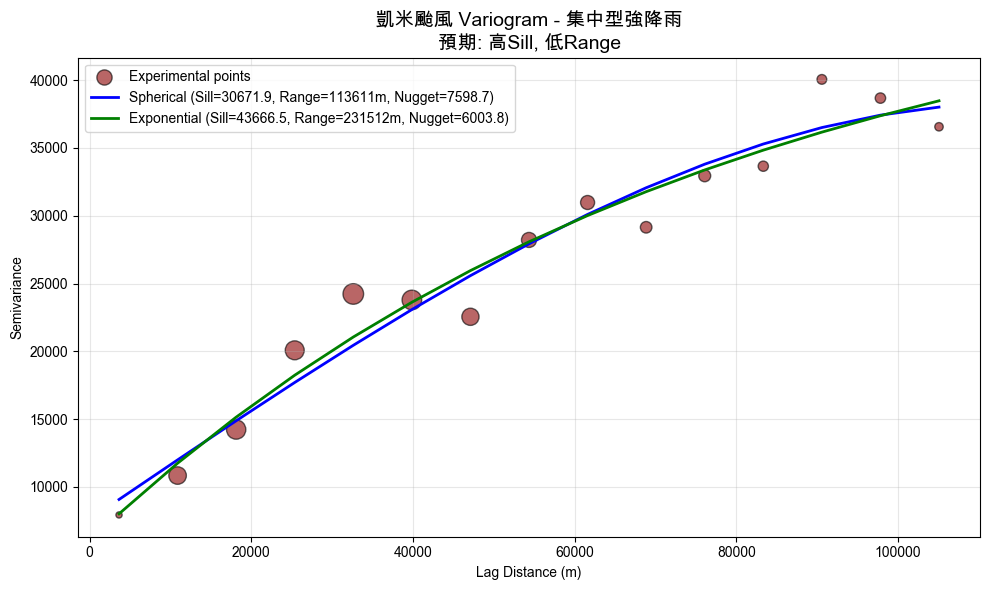

凱米颱風 Variogram Parameters:
  Spherical: Sill=30671.9, Range=113611m, Nugget=7598.7
  Exponential: Sill=43666.5, Range=231512m, Nugget=6003.8


=== Event 2: 梅雨鋒面 Variogram Analysis ===


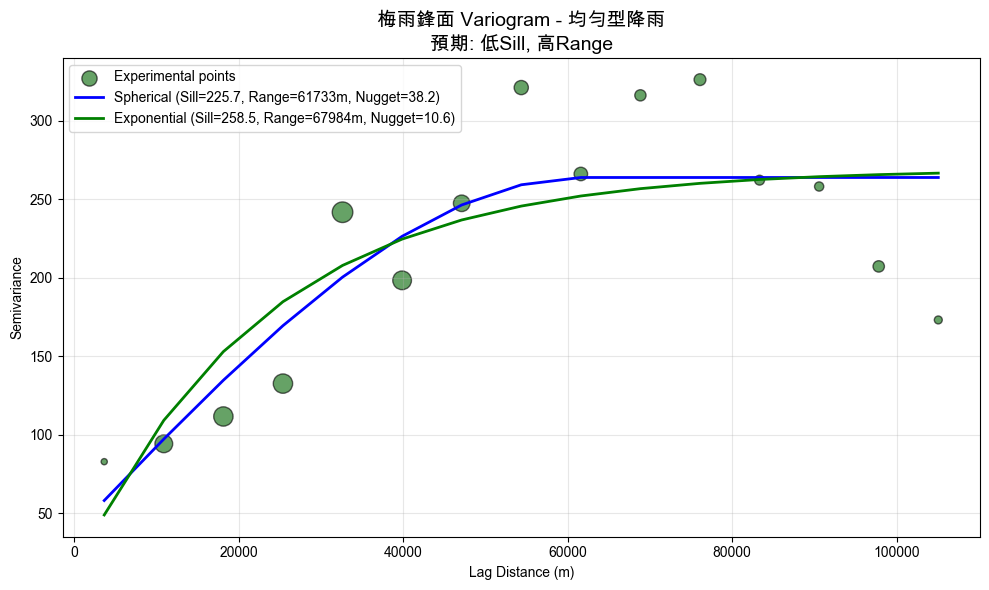

梅雨鋒面 Variogram Parameters:
  Spherical: Sill=225.7, Range=61733m, Nugget=38.2
  Exponential: Sill=258.5, Range=67984m, Nugget=10.6

Variogram 特性比較分析

🌪️ 凱米颱風 (集中型強降雨):
   - Sill (總變異): 30671.9
   - Range (空間相關範圍): 113611 m
   - Nugget (微觀變異): 7598.7

🌧️ 梅雨鋒面 (均勻型降雨):
   - Sill (總變異): 225.7
   - Range (空間相關範圍): 61733 m
   - Nugget (微觀變異): 38.2

📊 Variogram 特性對比:
   - Sill比較: 凱米颱風 (30671.9) > 梅雨鋒面 (225.7)
   → 凱米颱風空間變異較大，符合集中型降雨特徵
   - Range比較: 凱米颱風 (113611m) > 梅雨鋒面 (61733m)
   → 凱米颱風空間相關範圍較大，符合集中型降雨特徵

🔍 理論預期驗證:
   集中型降雨預期: 高Sill, 低Range
   均勻型降雨預期: 低Sill, 高Range
   實際結果是否符合預期: ❌ 否


In [34]:
# Variogram analysis for Event 1: 凱米颱風 (集中型強降雨)
print("=== Event 1: 凱米颱風 Variogram Analysis ===")

# Calculate experimental variogram
lags_kaimi, exp_vario_kaimi, counts_kaimi = calculate_experimental_variogram(
    df_kaimi['Easting'].values, 
    df_kaimi['Northing'].values, 
    df_kaimi['Past24hr'].values
)

# Fit theoretical models
models_kaimi = fit_variogram_models(lags_kaimi, exp_vario_kaimi)

# Plot variogram
fig, ax = plt.subplots(figsize=(10, 6))

# 設定白色背景
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 將 counts 正規化到 20 ~ 300 之間
sizes = (counts_kaimi - counts_kaimi.min()) / (counts_kaimi.max() - counts_kaimi.min())
sizes = sizes * 200 + 20 

# Plot experimental variogram
sc = ax.scatter(lags_kaimi, exp_vario_kaimi, s=sizes, alpha=0.6, 
               c='darkred', label='Experimental points', edgecolors='black')

# Plot fitted models
colors = {'spherical': 'blue', 'exponential': 'green'}
for model_type, model_data in models_kaimi.items():
    if model_data is not None:
        ax.plot(lags_kaimi, model_data['fitted_values'], 
               color=colors[model_type], linewidth=2, 
               label=f"{model_type.capitalize()} (Sill={model_data['params'][0]:.1f}, "
                     f"Range={model_data['params'][1]:.0f}m, Nugget={model_data['params'][2]:.1f})")

ax.set_xlabel('Lag Distance (m)')
ax.set_ylabel('Semivariance')
ax.set_title('凱米颱風 Variogram - 集中型強降雨\n預期: 高Sill, 低Range', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

# 儲存凱米颱風 Variogram 圖到 outputs 目錄 (在 show 之前儲存)
output_dir = '/Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/outputs'
print("正在儲存凱米颱風 Variogram 分析圖到 outputs 目錄...")
try:
    fig.savefig(f'{output_dir}/kaimi_variogram.png', 
                dpi=300, facecolor='white', edgecolor='none', 
                bbox_inches='tight', pad_inches=0.1)
    print("✅ 凱米颱風 Variogram 分析圖已儲存為 outputs/kaimi_variogram.png")
except Exception as e:
    print(f"❌ 儲存失敗: {e}")

plt.show()

# Print model parameters
print("凱米颱風 Variogram Parameters:")
for model_type, model_data in models_kaimi.items():
    if model_data is not None:
        sill, range_, nugget = model_data['params']
        print(f"  {model_type.capitalize()}: Sill={sill:.1f}, Range={range_:.0f}m, Nugget={nugget:.1f}")

# 檢查檔案大小
import os
file_path = f'{output_dir}/kaimi_variogram.png'
if os.path.exists(file_path):
    file_size = os.path.getsize(file_path)
    print(f"檔案大小: {file_size:,} bytes")
    if file_size > 50000:  # 如果大於50KB，應該是正常的
        print("✅ 檔案大小正常，圖片應該有內容")
    else:
        print("❌ 檔案太小，可能仍然是空白")

print("\n" + "="*50 + "\n")

# Variogram analysis for Event 2: 梅雨鋒面 (均勻型降雨)
print("=== Event 2: 梅雨鋒面 Variogram Analysis ===")

# Calculate experimental variogram
lags_meiyu, exp_vario_meiyu, counts_meiyu = calculate_experimental_variogram(
    df_meiyu['Easting'].values, 
    df_meiyu['Northing'].values, 
    df_meiyu['Past24hr'].values
)

# Fit theoretical models
models_meiyu = fit_variogram_models(lags_meiyu, exp_vario_meiyu)

# Plot variogram
fig, ax = plt.subplots(figsize=(10, 6))

# 設定白色背景
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 將 counts 正規化到 20 ~ 300 之間
sizes = (counts_meiyu - counts_meiyu.min()) / (counts_meiyu.max() - counts_meiyu.min())
sizes = sizes * 200 + 20 

# Plot experimental variogram
sc = ax.scatter(lags_meiyu, exp_vario_meiyu, s=sizes, alpha=0.6, 
               c='darkgreen', label='Experimental points', edgecolors='black')

# Plot fitted models
colors = {'spherical': 'blue', 'exponential': 'green'}
for model_type, model_data in models_meiyu.items():
    if model_data is not None:
        ax.plot(lags_meiyu, model_data['fitted_values'], 
               color=colors[model_type], linewidth=2, 
               label=f"{model_type.capitalize()} (Sill={model_data['params'][0]:.1f}, "
                     f"Range={model_data['params'][1]:.0f}m, Nugget={model_data['params'][2]:.1f})")

ax.set_xlabel('Lag Distance (m)')
ax.set_ylabel('Semivariance')
ax.set_title('梅雨鋒面 Variogram - 均勻型降雨\n預期: 低Sill, 高Range', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

# 儲存梅雨鋒面 Variogram 圖到 outputs 目錄 (在 show 之前儲存)
print("正在儲存梅雨鋒面 Variogram 分析圖到 outputs 目錄...")
try:
    fig.savefig(f'{output_dir}/meiyu_variogram.png', 
                dpi=300, facecolor='white', edgecolor='none', 
                bbox_inches='tight', pad_inches=0.1)
    print("✅ 梅雨鋒面 Variogram 分析圖已儲存為 outputs/meiyu_variogram.png")
except Exception as e:
    print(f"❌ 儲存失敗: {e}")

plt.show()

# Print model parameters
print("梅雨鋒面 Variogram Parameters:")
for model_type, model_data in models_meiyu.items():
    if model_data is not None:
        sill, range_, nugget = model_data['params']
        print(f"  {model_type.capitalize()}: Sill={sill:.1f}, Range={range_:.0f}m, Nugget={nugget:.1f}")

# 檢查檔案大小
file_path = f'{output_dir}/meiyu_variogram.png'
if os.path.exists(file_path):
    file_size = os.path.getsize(file_path)
    print(f"檔案大小: {file_size:,} bytes")
    if file_size > 50000:  # 如果大於50KB，應該是正常的
        print("✅ 檔案大小正常，圖片應該有內容")
    else:
        print("❌ 檔案太小，可能仍然是空白")

# Variogram 比較分析
print("\n" + "="*60)
print("Variogram 特性比較分析")
print("="*60)

# 取得最佳模型參數 (使用spherical模型)
if 'spherical' in models_kaimi and models_kaimi['spherical'] is not None:
    sill_kaimi, range_kaimi, nugget_kaimi = models_kaimi['spherical']['params']
else:
    # 如果spherical失敗，使用exponential
    if 'exponential' in models_kaimi and models_kaimi['exponential'] is not None:
        sill_kaimi, range_kaimi, nugget_kaimi = models_kaimi['exponential']['params']
    else:
        sill_kaimi, range_kaimi, nugget_kaimi = 0, 0, 0

if 'spherical' in models_meiyu and models_meiyu['spherical'] is not None:
    sill_meiyu, range_meiyu, nugget_meiyu = models_meiyu['spherical']['params']
else:
    # 如果spherical失敗，使用exponential
    if 'exponential' in models_meiyu and models_meiyu['exponential'] is not None:
        sill_meiyu, range_meiyu, nugget_meiyu = models_meiyu['exponential']['params']
    else:
        sill_meiyu, range_meiyu, nugget_meiyu = 0, 0, 0

print(f"\n🌪️ 凱米颱風 (集中型強降雨):")
print(f"   - Sill (總變異): {sill_kaimi:.1f}")
print(f"   - Range (空間相關範圍): {range_kaimi:.0f} m")
print(f"   - Nugget (微觀變異): {nugget_kaimi:.1f}")

print(f"\n🌧️ 梅雨鋒面 (均勻型降雨):")
print(f"   - Sill (總變異): {sill_meiyu:.1f}")
print(f"   - Range (空間相關範圍): {range_meiyu:.0f} m")
print(f"   - Nugget (微觀變異): {nugget_meiyu:.1f}")

print(f"\n📊 Variogram 特性對比:")
if sill_kaimi > sill_meiyu:
    print(f"   - Sill比較: 凱米颱風 ({sill_kaimi:.1f}) > 梅雨鋒面 ({sill_meiyu:.1f})")
    print(f"   → 凱米颱風空間變異較大，符合集中型降雨特徵")
else:
    print(f"   - Sill比較: 梅雨鋒面 ({sill_meiyu:.1f}) > 凱米颱風 ({sill_kaimi:.1f})")
    print(f"   → 梅雨鋒面空間變異較大，符合均勻型降雨特徵")

if range_meiyu > range_kaimi:
    print(f"   - Range比較: 梅雨鋒面 ({range_meiyu:.0f}m) > 凱米颱風 ({range_kaimi:.0f}m)")
    print(f"   → 梅雨鋒面空間相關範圍較大，符合均勻型降雨特徵")
else:
    print(f"   - Range比較: 凱米颱風 ({range_kaimi:.0f}m) > 梅雨鋒面 ({range_meiyu:.0f}m)")
    print(f"   → 凱米颱風空間相關範圍較大，符合集中型降雨特徵")

# 理論預期驗證
print(f"\n🔍 理論預期驗證:")
print(f"   集中型降雨預期: 高Sill, 低Range")
print(f"   均勻型降雨預期: 低Sill, 高Range")
print(f"   實際結果是否符合預期: {'✅ 是' if (sill_kaimi > sill_meiyu and range_meiyu > range_kaimi) else '❌ 否'}")

In [7]:
# Interpolation functions
def create_grid(df, resolution=1000):
    """
    Create interpolation grid
    """
    min_easting, max_easting = df['Easting'].min(), df['Easting'].max()
    min_northing, max_northing = df['Northing'].min(), df['Northing'].max()
    
    # Add buffer
    buffer = 10000  # 10km buffer
    min_easting -= buffer
    max_easting += buffer
    min_northing -= buffer
    max_northing += buffer
    
    # Create grid
    xi = np.arange(min_easting, max_easting, resolution)
    yi = np.arange(min_northing, max_northing, resolution)
    xi_grid, yi_grid = np.meshgrid(xi, yi)
    
    return xi_grid, yi_grid, xi, yi

def nearest_neighbor_interpolation(x_obs, y_obs, values, xi_grid, yi_grid):
    """
    Nearest Neighbor interpolation
    """
    points = np.column_stack([x_obs, y_obs])
    interpolator = NearestNDInterpolator(points, values)
    
    grid_points = np.column_stack([xi_grid.ravel(), yi_grid.ravel()])
    zi = interpolator(grid_points)
    
    return zi.reshape(xi_grid.shape)

def idw_interpolation(x_obs, y_obs, values, xi_grid, yi_grid, power=2):
    """
    Inverse Distance Weighted interpolation
    """
    grid_points = np.column_stack([xi_grid.ravel(), yi_grid.ravel()])
    obs_points = np.column_stack([x_obs, y_obs])
    
    # Calculate distances
    distances = distance.cdist(grid_points, obs_points)
    
    # Avoid division by zero
    distances[distances == 0] = 1e-10
    
    # Calculate weights
    weights = 1 / (distances ** power)
    weights_sum = np.sum(weights, axis=1, keepdims=True)
    
    # Calculate weighted average
    zi = np.sum(weights * values, axis=1) / weights_sum.ravel()
    
    return zi.reshape(xi_grid.shape)

def kriging_interpolation(x_obs, y_obs, values, xi_grid, yi_grid, model_type='spherical'):
    """
    Ordinary Kriging interpolation
    """
    # Create grid coordinates
    xi = xi_grid[0, :]
    yi = yi_grid[:, 0]
    
    # Fit variogram parameters (simplified - using first model)
    lags, exp_vario, counts = calculate_experimental_variogram(x_obs, y_obs, values)
    models = fit_variogram_models(lags, exp_vario, [model_type])
    
    if model_type not in models or models[model_type] is None:
        print(f"Failed to fit {model_type} model, using default parameters")
        # Default parameters
        sill, range_, nugget = np.var(values), np.max(lags) * 0.3, 0
    else:
        sill, range_, nugget = models[model_type]['params']
    
    # Perform Ordinary Kriging
    ok = OrdinaryKriging(
        x_obs, y_obs, values,
        variogram_model=model_type,
        variogram_parameters=[sill, range_, nugget],
        verbose=False,
        enable_plotting=False
    )
    
    # Interpolate to grid
    z, sigma = ok.execute('grid', xi, yi)
    
    return z, sigma

def random_forest_interpolation(x_obs, y_obs, values, xi_grid, yi_grid, n_estimators=200, min_samples_leaf=3):
    """
    Random Forest interpolation
    """
    # Prepare training data
    X_train = np.column_stack([x_obs, y_obs])
    y_train = values
    
    # Train Random Forest
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    
    # Predict on grid
    grid_points = np.column_stack([xi_grid.ravel(), yi_grid.ravel()])
    zi = rf.predict(grid_points)
    
    return zi.reshape(xi_grid.shape)

print("Interpolation functions defined!")

Interpolation functions defined!


In [8]:
# Interpolation for Event 1: 凱米颱風
print("=== Event 1: 凱米颱風 Interpolation ===")

# Create grid
xi_grid_kaimi, yi_grid_kaimi, xi_kaimi, yi_kaimi = create_grid(df_kaimi, resolution=1000)
print(f"Grid created: {xi_grid_kaimi.shape[0]} x {xi_grid_kaimi.shape[1]} = {xi_grid_kaimi.size} points")

# Extract observation data
x_obs_kaimi = df_kaimi['Easting'].values
y_obs_kaimi = df_kaimi['Northing'].values
values_kaimi = df_kaimi['Past24hr'].values

# Perform interpolations
print("Performing Nearest Neighbor...")
nn_kaimi = nearest_neighbor_interpolation(x_obs_kaimi, y_obs_kaimi, values_kaimi, xi_grid_kaimi, yi_grid_kaimi)

print("Performing IDW...")
idw_kaimi = idw_interpolation(x_obs_kaimi, y_obs_kaimi, values_kaimi, xi_grid_kaimi, yi_grid_kaimi, power=2)

print("Performing Ordinary Kriging...")
kriging_kaimi, sigma_kaimi = kriging_interpolation(x_obs_kaimi, y_obs_kaimi, values_kaimi, 
                                                   xi_grid_kaimi, yi_grid_kaimi, model_type='spherical')

print("Performing Random Forest...")
rf_kaimi = random_forest_interpolation(x_obs_kaimi, y_obs_kaimi, values_kaimi, 
                                       xi_grid_kaimi, yi_grid_kaimi, n_estimators=200, min_samples_leaf=3)

print("Event 1 interpolation completed!")

=== Event 1: 凱米颱風 Interpolation ===
Grid created: 227 x 98 = 22246 points
Performing Nearest Neighbor...


Performing IDW...
Performing Ordinary Kriging...
Performing Random Forest...
Event 1 interpolation completed!


=== 正在生成凱米颱風內插比較圖 ===
✅ 修正後的凱米颱風比較圖已儲存：/Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/outputs/kaimi_comparison_2x2_fixed.png


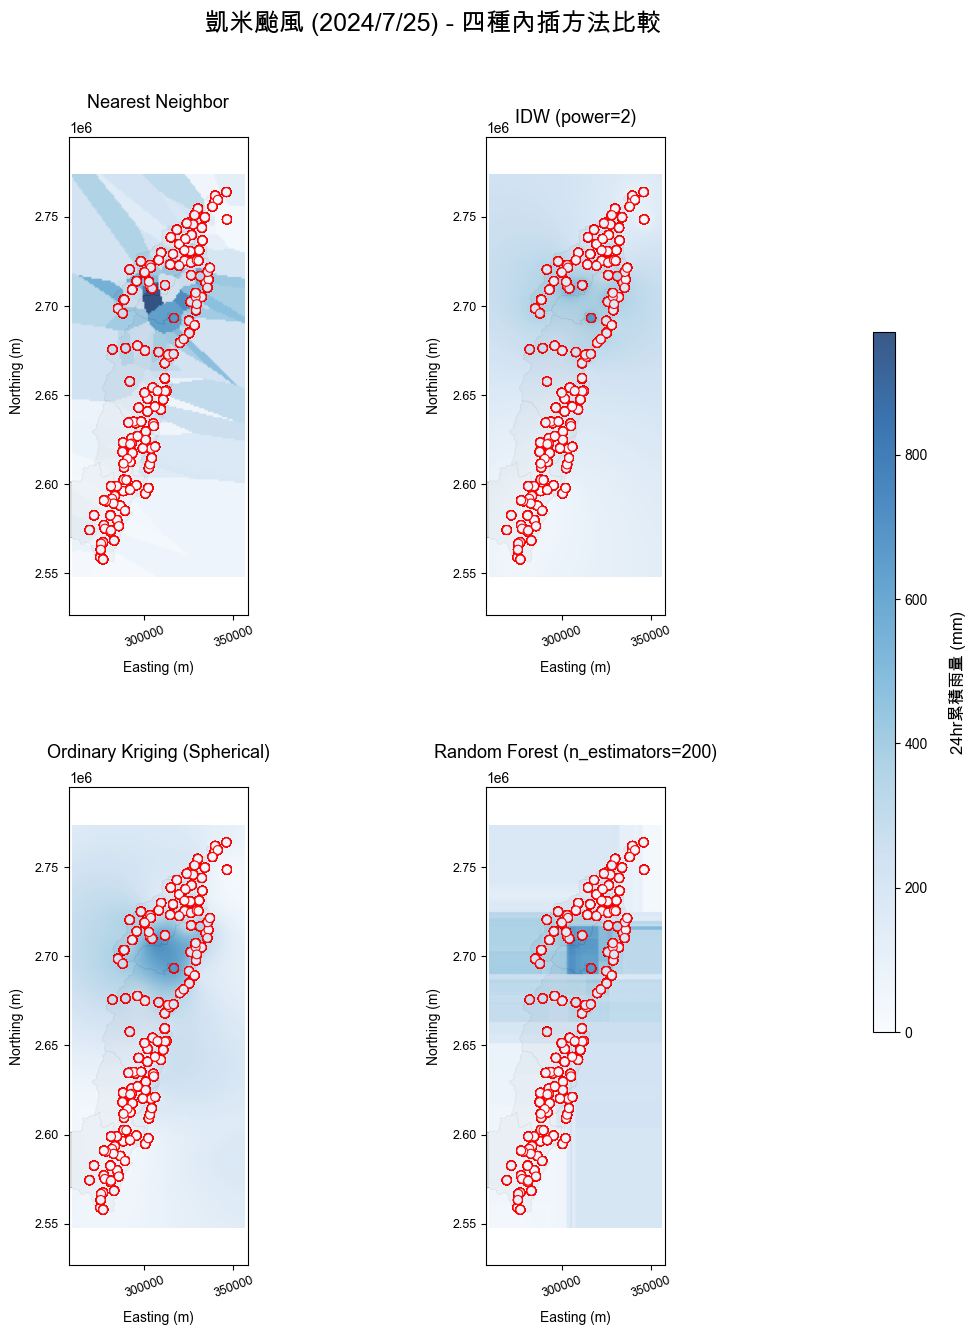

In [35]:
import matplotlib.pyplot as plt
import os

print("=== 正在生成凱米颱風內插比較圖 ===")

# 1. 調整畫布比例：改為 (10, 14) 或 (12, 14)，地圖瘦長型適合較窄的寬度
fig, axes = plt.subplots(2, 2, figsize=(11, 14))
fig.suptitle('凱米颱風 (2024/7/25) - 四種內插方法比較', fontsize=18, fontweight='bold', y=0.98)

fig.patch.set_facecolor('white')

# Common colorbar limits
vmin, vmax = 0, max(np.nanmax(nn_kaimi), np.nanmax(idw_kaimi), np.nanmax(kriging_kaimi), np.nanmax(rf_kaimi))

# 繪製邏輯
methods = [
    (nn_kaimi, 'Nearest Neighbor'),
    (idw_kaimi, 'IDW (power=2)'),
    (kriging_kaimi, 'Ordinary Kriging (Spherical)'),
    (rf_kaimi, 'Random Forest (n_estimators=200)')
]

for i, (data, title) in enumerate(methods):
    ax = axes.flat[i]
    ax.set_facecolor('white')
    
    # 繪製底圖
    if towns_filtered is not None:
        towns_filtered[towns_filtered['COUNTYNAME'].isin(['花蓮縣', '宜蘭縣'])].plot(
            ax=ax, facecolor='lightgray', edgecolor='gray', 
            linewidth=0.5, alpha=0.7, zorder=1
        )
        # 使用你定義的 plot_x_min 等範圍確保地圖置中且比例正確
        ax.set_xlim(plot_x_min, plot_x_max)
        ax.set_ylim(plot_y_min, plot_y_max)

    # 繪製內插結果
    im = ax.imshow(data, extent=[xi_kaimi.min(), xi_kaimi.max(), yi_kaimi.min(), yi_kaimi.max()],
                   cmap='Blues', vmin=vmin, vmax=vmax, origin='lower', alpha=0.8, zorder=2)
    
    # 繪製觀測點
    ax.scatter(x_obs_kaimi, y_obs_kaimi, c=values_kaimi, s=40, cmap='Blues', 
               edgecolors='red', linewidth=0.8, vmin=vmin, vmax=vmax, zorder=3)
    
    # 設定標籤與標題
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Easting (m)', fontsize=10, labelpad=8)
    ax.set_ylabel('Northing (m)', fontsize=10, labelpad=8)
    
    # 旋轉 X 軸刻度避免重疊，並縮小刻度字體
    ax.tick_params(axis='x', labelsize=9, labelrotation=20)
    ax.tick_params(axis='y', labelsize=9)

# 2. 自動調整布局：rect 留出右側 (0.88) 給 Colorbar，h_pad 增加上下間距
fig.tight_layout(rect=[0, 0.03, 0.88, 0.96], h_pad=5.0, w_pad=2.5)

# 3. 獨立 Colorbar 座標軸 [左, 下, 寬, 高]
cax = fig.add_axes([0.90, 0.25, 0.02, 0.5]) 
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('24hr累積雨量 (mm)', fontsize=12, fontweight='bold', labelpad=15)
cbar.ax.tick_params(labelsize=10)

# 儲存與顯示
output_dir = '/Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

try:
    save_path = f'{output_dir}/kaimi_comparison_2x2_fixed.png'
    fig.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.2)
    print(f"✅ 修正後的凱米颱風比較圖已儲存：{save_path}")
except Exception as e:
    print(f"❌ 儲存失敗: {e}")

plt.show()

In [10]:
# Interpolation for Event 2: 梅雨鋒面
print("=== Event 2: 梅雨鋒面 Interpolation ===")

# Create grid
xi_grid_meiyu, yi_grid_meiyu, xi_meiyu, yi_meiyu = create_grid(df_meiyu, resolution=1000)
print(f"Grid created: {xi_grid_meiyu.shape[0]} x {xi_grid_meiyu.shape[1]} = {xi_grid_meiyu.size} points")

# Extract observation data
x_obs_meiyu = df_meiyu['Easting'].values
y_obs_meiyu = df_meiyu['Northing'].values
values_meiyu = df_meiyu['Past24hr'].values

# Perform interpolations
print("Performing Nearest Neighbor...")
nn_meiyu = nearest_neighbor_interpolation(x_obs_meiyu, y_obs_meiyu, values_meiyu, xi_grid_meiyu, yi_grid_meiyu)

print("Performing IDW...")
idw_meiyu = idw_interpolation(x_obs_meiyu, y_obs_meiyu, values_meiyu, xi_grid_meiyu, yi_grid_meiyu, power=2)

print("Performing Ordinary Kriging...")
kriging_meiyu, sigma_meiyu = kriging_interpolation(x_obs_meiyu, y_obs_meiyu, values_meiyu, 
                                                   xi_grid_meiyu, yi_grid_meiyu, model_type='spherical')

print("Performing Random Forest...")
rf_meiyu = random_forest_interpolation(x_obs_meiyu, y_obs_meiyu, values_meiyu, 
                                       xi_grid_meiyu, yi_grid_meiyu, n_estimators=200, min_samples_leaf=3)

print("Event 2 interpolation completed!")

=== Event 2: 梅雨鋒面 Interpolation ===
Grid created: 227 x 98 = 22246 points
Performing Nearest Neighbor...
Performing IDW...
Performing Ordinary Kriging...
Performing Random Forest...
Event 2 interpolation completed!


=== 正在生成梅雨鋒面內插比較圖 ===
✅ 修正後的梅雨鋒面比較圖已儲存：/Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/outputs/meiyu_comparison_2x2_fixed.png


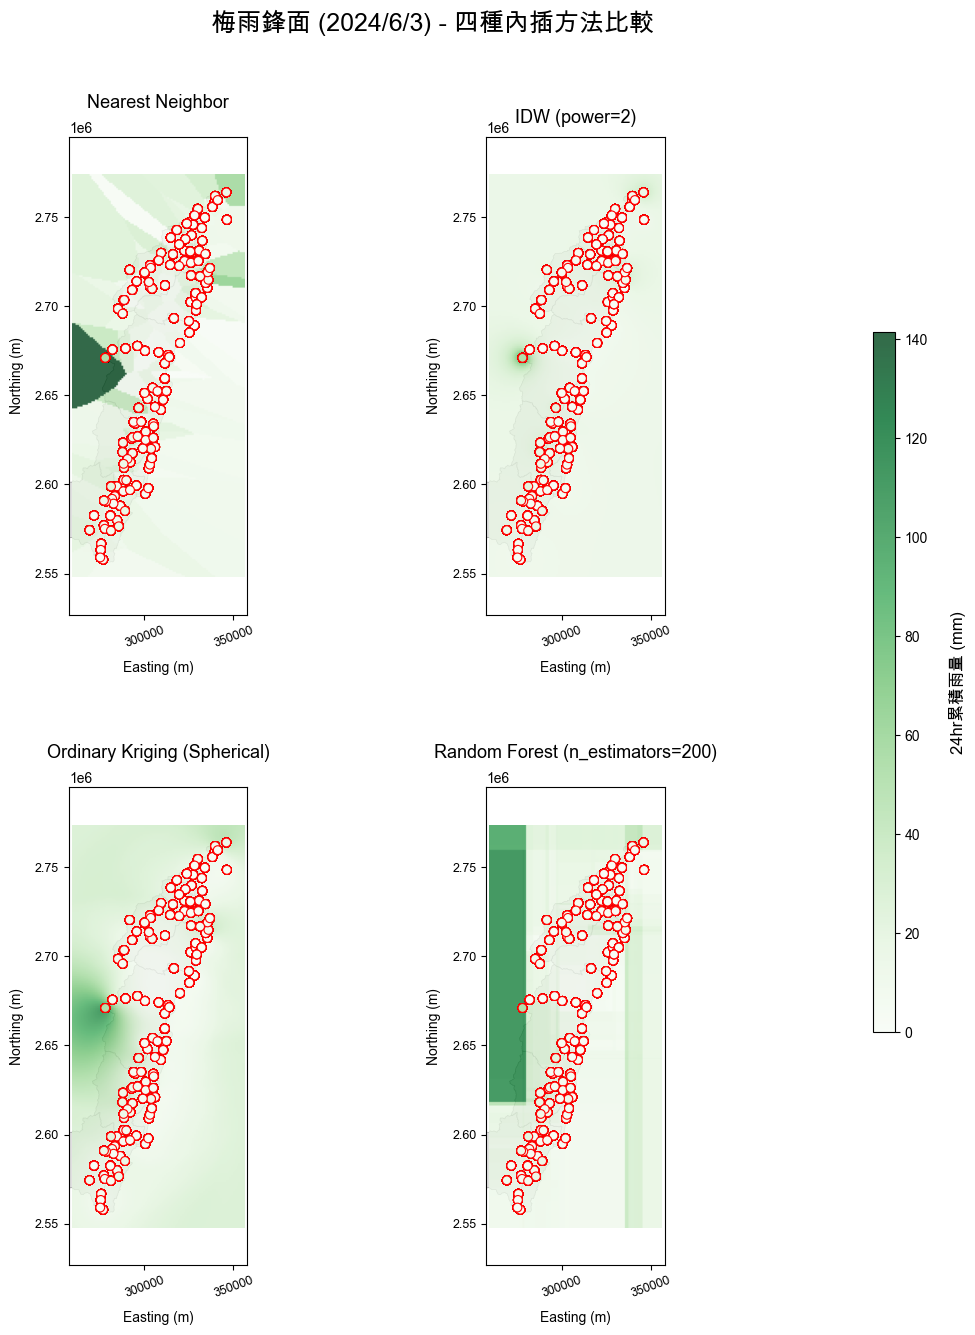

In [36]:
import matplotlib.pyplot as plt
import os

print("=== 正在生成梅雨鋒面內插比較圖 ===")

# 1. 調整畫布比例：改為 (10, 14) 或 (12, 14)，地圖瘦長型適合較窄的寬度
fig, axes = plt.subplots(2, 2, figsize=(11, 14))
fig.suptitle('梅雨鋒面 (2024/6/3) - 四種內插方法比較', fontsize=18, fontweight='bold', y=0.98)

fig.patch.set_facecolor('white')

# Common colorbar limits
vmin, vmax = 0, max(np.nanmax(nn_meiyu), np.nanmax(idw_meiyu), np.nanmax(kriging_meiyu), np.nanmax(rf_meiyu))

# 繪製邏輯
methods = [
    (nn_meiyu, 'Nearest Neighbor'),
    (idw_meiyu, 'IDW (power=2)'),
    (kriging_meiyu, 'Ordinary Kriging (Spherical)'),
    (rf_meiyu, 'Random Forest (n_estimators=200)')
]

for i, (data, title) in enumerate(methods):
    ax = axes.flat[i]
    ax.set_facecolor('white')
    
    # 繪製底圖
    if towns_filtered is not None:
        towns_filtered[towns_filtered['COUNTYNAME'].isin(['花蓮縣', '宜蘭縣'])].plot(
            ax=ax, facecolor='lightgray', edgecolor='gray', 
            linewidth=0.5, alpha=0.7, zorder=1
        )
        # 使用你定義的 plot_x_min 等範圍確保地圖置中且比例正確
        ax.set_xlim(plot_x_min, plot_x_max)
        ax.set_ylim(plot_y_min, plot_y_max)

    # 繪製內插結果
    im = ax.imshow(data, extent=[xi_meiyu.min(), xi_meiyu.max(), yi_meiyu.min(), yi_meiyu.max()],
                   cmap='Greens', vmin=vmin, vmax=vmax, origin='lower', alpha=0.8, zorder=2)
    
    # 繪製觀測點
    ax.scatter(x_obs_meiyu, y_obs_meiyu, c=values_meiyu, s=40, cmap='Greens', 
               edgecolors='red', linewidth=0.8, vmin=vmin, vmax=vmax, zorder=3)
    
    # 設定標籤與標題
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Easting (m)', fontsize=10, labelpad=8)
    ax.set_ylabel('Northing (m)', fontsize=10, labelpad=8)
    
    # 旋轉 X 軸刻度避免重疊，並縮小刻度字體
    ax.tick_params(axis='x', labelsize=9, labelrotation=20)
    ax.tick_params(axis='y', labelsize=9)

# 2. 自動調整布局：rect 留出右側 (0.88) 給 Colorbar，h_pad 增加上下間距
fig.tight_layout(rect=[0, 0.03, 0.88, 0.96], h_pad=5.0, w_pad=2.5)

# 3. 獨立 Colorbar 座標軸 [左, 下, 寬, 高]
cax = fig.add_axes([0.90, 0.25, 0.02, 0.5]) 
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('24hr累積雨量 (mm)', fontsize=12, fontweight='bold', labelpad=15)
cbar.ax.tick_params(labelsize=10)

# 儲存與顯示
output_dir = '/Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

try:
    save_path = f'{output_dir}/meiyu_comparison_2x2_fixed.png'
    fig.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.2)
    print(f"✅ 修正後的梅雨鋒面比較圖已儲存：{save_path}")
except Exception as e:
    print(f"❌ 儲存失敗: {e}")

plt.show()

=== 正在生成凱米颱風 Kriging vs Random Forest 比較圖 ===
正在儲存凱米颱風 Kriging vs Random Forest 比較圖到 outputs 目錄...
✅ 凱米颱風 Kriging vs Random Forest 比較圖已儲存為 outputs/kaimi_kriging_vs_rf.png


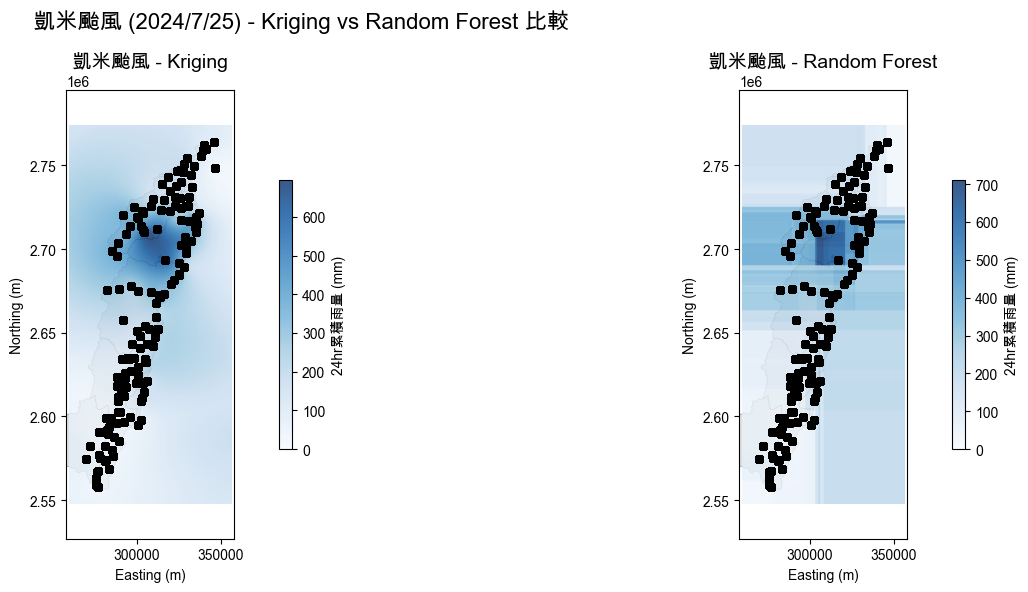

凱米颱風 - 平均差異: -15.29 mm, 標準差: 62.40 mm
檔案大小: 285,374 bytes
✅ 檔案大小正常，圖片應該有內容
=== 凱米颱風 Kriging vs Random Forest 比較圖完成 ===
=== 正在生成梅雨鋒面 Kriging vs Random Forest 比較圖 ===
正在儲存梅雨鋒面 Kriging vs Random Forest 比較圖到 outputs 目錄...
✅ 梅雨鋒面 Kriging vs Random Forest 比較圖已儲存為 outputs/meiyu_kriging_vs_rf.png


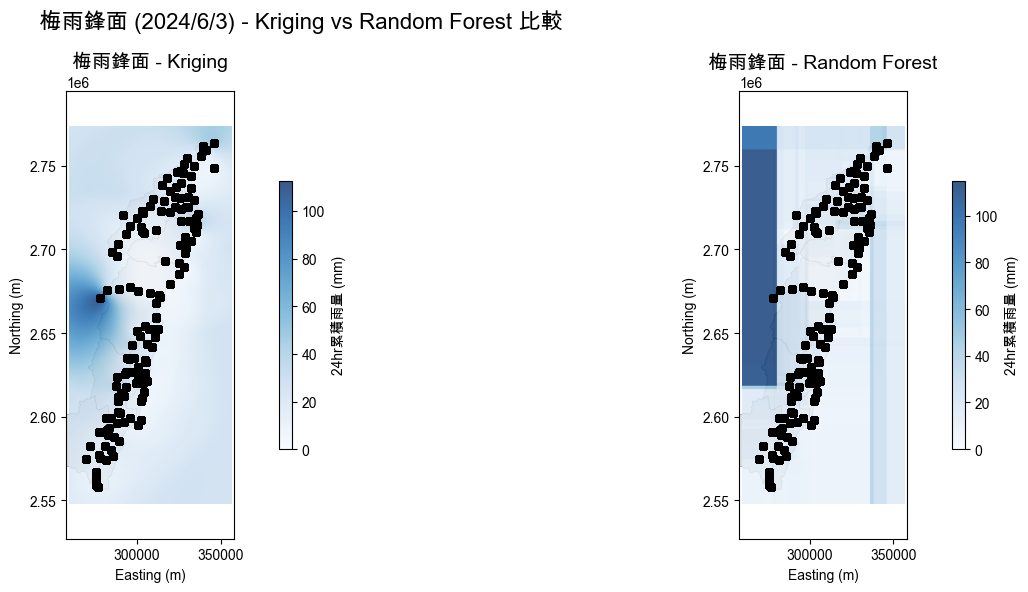

梅雨鋒面 - 平均差異: -5.84 mm, 標準差: 26.40 mm
檔案大小: 268,147 bytes
✅ 檔案大小正常，圖片應該有內容
=== 梅雨鋒面 Kriging vs Random Forest 比較圖完成 ===


In [37]:
# Kriging vs Random Forest 比較圖 - Event 1: 凱米颱風
print("=== 正在生成凱米颱風 Kriging vs Random Forest 比較圖 ===")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('凱米颱風 (2024/7/25) - Kriging vs Random Forest 比較', fontsize=16, fontweight='bold')

# 設定白色背景
fig.patch.set_facecolor('white')
for ax in axes.flat:
    ax.set_facecolor('white')

# 計算差異
diff_kaimi = kriging_kaimi - rf_kaimi
vmax_kaimi = max(np.abs(diff_kaimi.min()), np.abs(diff_kaimi.max()))

# 為每個子圖添加鄉鎮邊界底圖（只顯示台灣本島，移除離島）
for ax in axes.flat:
    if towns_filtered is not None:
        # Plot town boundaries for 花蓮縣 and 宜蘭縣（只顯示本島部分）
        towns_filtered[towns_filtered['COUNTYNAME'] == '花蓮縣'].plot(
            ax=ax, facecolor='lightgray', edgecolor='gray', 
            linewidth=0.5, alpha=0.7, zorder=1
        )
        towns_filtered[towns_filtered['COUNTYNAME'] == '宜蘭縣'].plot(
            ax=ax, facecolor='lightgray', edgecolor='gray', 
            linewidth=0.5, alpha=0.7, zorder=1
        )
        # 設定置中顯示範圍（使用之前計算的範圍，確保只顯示本島）
        ax.set_xlim(plot_x_min, plot_x_max)
        ax.set_ylim(plot_y_min, plot_y_max)

# Kriging 結果
im1 = axes[0].imshow(kriging_kaimi, extent=[xi_kaimi.min(), xi_kaimi.max(), yi_kaimi.min(), yi_kaimi.max()],
                     cmap='Blues', vmin=0, vmax=np.nanmax(kriging_kaimi), origin='lower', alpha=0.8, zorder=2)
axes[0].scatter(x_obs_kaimi, y_obs_kaimi, c='black', s=30, alpha=0.5, zorder=3)
axes[0].set_title('凱米颱風 - Kriging', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')

# Random Forest 結果
im2 = axes[1].imshow(rf_kaimi, extent=[xi_kaimi.min(), xi_kaimi.max(), yi_kaimi.min(), yi_kaimi.max()],
                     cmap='Blues', vmin=0, vmax=np.nanmax(rf_kaimi), origin='lower', alpha=0.8, zorder=2)
axes[1].scatter(x_obs_kaimi, y_obs_kaimi, c='black', s=30, alpha=0.5, zorder=3)
axes[1].set_title('凱米颱風 - Random Forest', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')

# 添加 colorbar
cbar1 = fig.colorbar(im1, ax=axes[0], shrink=0.6, label='24hr累積雨量 (mm)')
cbar2 = fig.colorbar(im2, ax=axes[1], shrink=0.6, label='24hr累積雨量 (mm)')

plt.tight_layout()

# 儲存圖片到 outputs 目錄 (在 show 之前儲存)
output_dir = '/Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/outputs'
print("正在儲存凱米颱風 Kriging vs Random Forest 比較圖到 outputs 目錄...")
try:
    fig.savefig(f'{output_dir}/kaimi_kriging_vs_rf.png', 
                dpi=300, facecolor='white', edgecolor='none', 
                bbox_inches='tight', pad_inches=0.1)
    print("✅ 凱米颱風 Kriging vs Random Forest 比較圖已儲存為 outputs/kaimi_kriging_vs_rf.png")
except Exception as e:
    print(f"❌ 儲存失敗: {e}")

plt.show()

# 差異分析
print(f"凱米颱風 - 平均差異: {np.nanmean(diff_kaimi):.2f} mm, 標準差: {np.nanstd(diff_kaimi):.2f} mm")

# 檢查檔案大小
import os
file_path = f'{output_dir}/kaimi_kriging_vs_rf.png'
if os.path.exists(file_path):
    file_size = os.path.getsize(file_path)
    print(f"檔案大小: {file_size:,} bytes")
    if file_size > 50000:  # 如果大於50KB，應該是正常的
        print("✅ 檔案大小正常，圖片應該有內容")
    else:
        print("❌ 檔案太小，可能仍然是空白")

print("=== 凱米颱風 Kriging vs Random Forest 比較圖完成 ===")

# Kriging vs Random Forest 比較圖 - Event 2: 梅雨鋒面
print("=== 正在生成梅雨鋒面 Kriging vs Random Forest 比較圖 ===")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('梅雨鋒面 (2024/6/3) - Kriging vs Random Forest 比較', fontsize=16, fontweight='bold')

# 設定白色背景
fig.patch.set_facecolor('white')
for ax in axes.flat:
    ax.set_facecolor('white')

# 計算差異
diff_meiyu = kriging_meiyu - rf_meiyu
vmax_meiyu = max(np.abs(diff_meiyu.min()), np.abs(diff_meiyu.max()))

# 為每個子圖添加鄉鎮邊界底圖（只顯示台灣本島，移除離島）
for ax in axes.flat:
    if towns_filtered is not None:
        # Plot town boundaries for 花蓮縣 and 宜蘭縣（只顯示本島部分）
        towns_filtered[towns_filtered['COUNTYNAME'] == '花蓮縣'].plot(
            ax=ax, facecolor='lightgray', edgecolor='gray', 
            linewidth=0.5, alpha=0.7, zorder=1
        )
        towns_filtered[towns_filtered['COUNTYNAME'] == '宜蘭縣'].plot(
            ax=ax, facecolor='lightgray', edgecolor='gray', 
            linewidth=0.5, alpha=0.7, zorder=1
        )
        # 設定置中顯示範圍（使用之前計算的範圍，確保只顯示本島）
        ax.set_xlim(plot_x_min, plot_x_max)
        ax.set_ylim(plot_y_min, plot_y_max)

# Kriging 結果
im1 = axes[0].imshow(kriging_meiyu, extent=[xi_meiyu.min(), xi_meiyu.max(), yi_meiyu.min(), yi_meiyu.max()],
                     cmap='Blues', vmin=0, vmax=np.nanmax(kriging_meiyu), origin='lower', alpha=0.8, zorder=2)
axes[0].scatter(x_obs_meiyu, y_obs_meiyu, c='black', s=30, alpha=0.5, zorder=3)
axes[0].set_title('梅雨鋒面 - Kriging', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')

# Random Forest 結果
im2 = axes[1].imshow(rf_meiyu, extent=[xi_meiyu.min(), xi_meiyu.max(), yi_meiyu.min(), yi_meiyu.max()],
                     cmap='Blues', vmin=0, vmax=np.nanmax(rf_meiyu), origin='lower', alpha=0.8, zorder=2)
axes[1].scatter(x_obs_meiyu, y_obs_meiyu, c='black', s=30, alpha=0.5, zorder=3)
axes[1].set_title('梅雨鋒面 - Random Forest', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')

# 添加 colorbar
cbar1 = fig.colorbar(im1, ax=axes[0], shrink=0.6, label='24hr累積雨量 (mm)')
cbar2 = fig.colorbar(im2, ax=axes[1], shrink=0.6, label='24hr累積雨量 (mm)')

plt.tight_layout()

# 儲存圖片到 outputs 目錄 (在 show 之前儲存)
print("正在儲存梅雨鋒面 Kriging vs Random Forest 比較圖到 outputs 目錄...")
try:
    fig.savefig(f'{output_dir}/meiyu_kriging_vs_rf.png', 
                dpi=300, facecolor='white', edgecolor='none', 
                bbox_inches='tight', pad_inches=0.1)
    print("✅ 梅雨鋒面 Kriging vs Random Forest 比較圖已儲存為 outputs/meiyu_kriging_vs_rf.png")
except Exception as e:
    print(f"❌ 儲存失敗: {e}")

plt.show()

# 差異分析
print(f"梅雨鋒面 - 平均差異: {np.nanmean(diff_meiyu):.2f} mm, 標準差: {np.nanstd(diff_meiyu):.2f} mm")

# 檢查檔案大小
file_path = f'{output_dir}/meiyu_kriging_vs_rf.png'
if os.path.exists(file_path):
    file_size = os.path.getsize(file_path)
    print(f"檔案大小: {file_size:,} bytes")
    if file_size > 50000:  # 如果大於50KB，應該是正常的
        print("✅ 檔案大小正常，圖片應該有內容")
    else:
        print("❌ 檔案太小，可能仍然是空白")

print("=== 梅雨鋒面 Kriging vs Random Forest 比較圖完成 ===")

=== A3. 不確定性分析 - Sigma Map 視覺化 ===
正在生成凱米颱風 Sigma Map...
正在儲存凱米颱風 Sigma Map 到 outputs 目錄...
✅ 凱米颱風 Sigma Map 已儲存為 outputs/kaimi_sigma_map.png


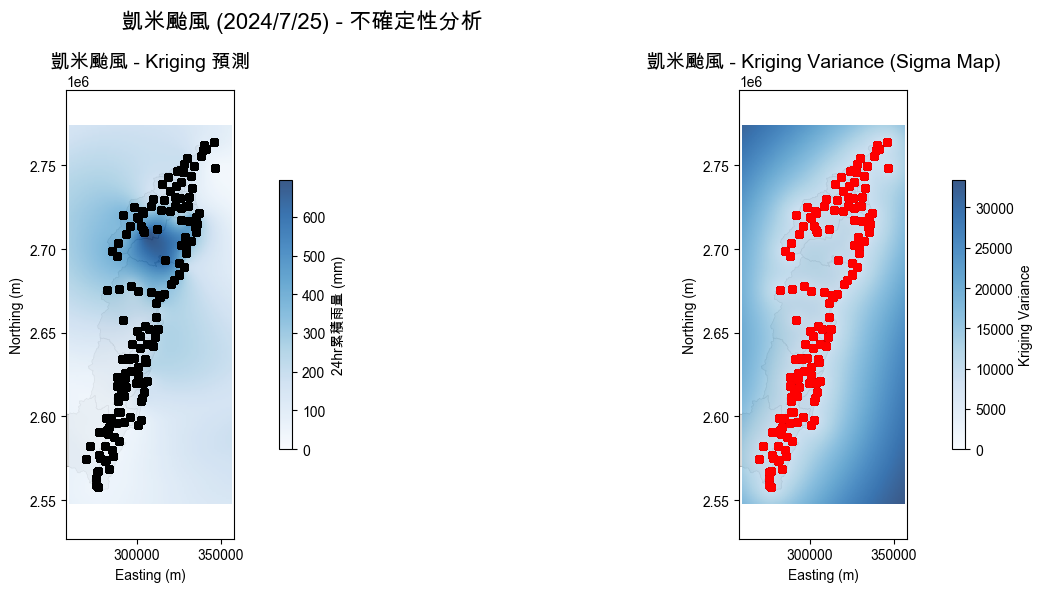

正在生成梅雨鋒面 Sigma Map...
正在儲存梅雨鋒面 Sigma Map 到 outputs 目錄...
✅ 梅雨鋒面 Sigma Map 已儲存為 outputs/meiyu_sigma_map.png


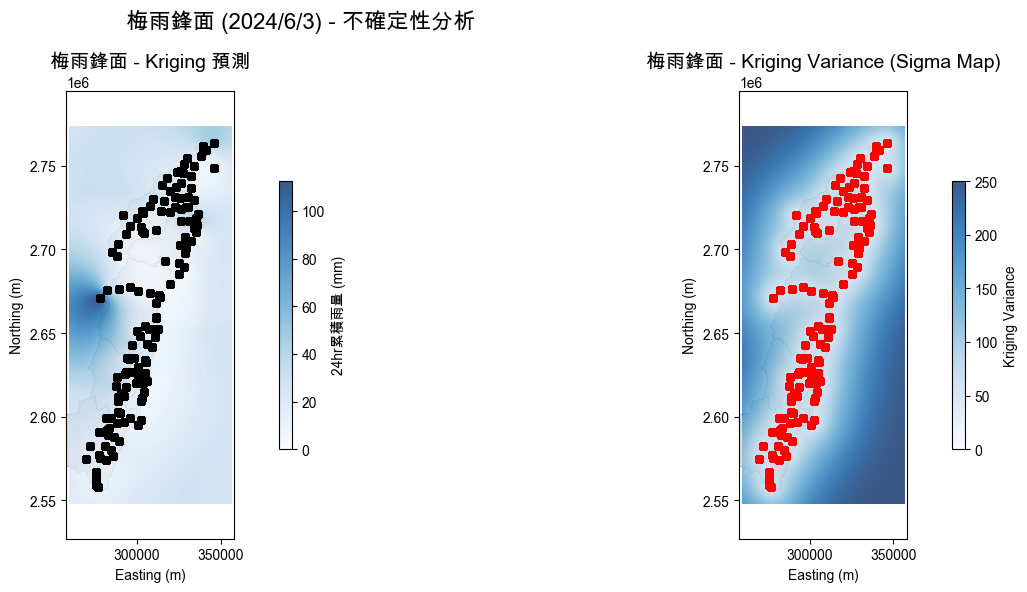


Sigma Map 統計分析

🌪️ 凱米颱風 Sigma Map 統計:
   - 平均 Variance: 14884.81
   - 標準差: 6109.79
   - 最小值: 7668.26
   - 最大值: 33418.06
   - 高 Variance 比例 (>平均+1std): 18.1%

🌧️ 梅雨鋒面 Sigma Map 統計:
   - 平均 Variance: 131.06
   - 標準差: 65.98
   - 最小值: 38.73
   - 最大值: 250.58
   - 高 Variance 比例 (>平均+1std): 21.7%

📊 不確定性比較:
   - 平均 Variance: 凱米颱風 (14884.81) > 梅雨鋒面 (131.06)
   → 凱米颱風預測不確定性較高
=== Sigma Map 視覺化完成 ===


In [38]:
# A3. 不確定性分析 - Sigma Map 視覺化
print("=== A3. 不確定性分析 - Sigma Map 視覺化 ===")

# Event 1: 凱米颱風 Sigma Map
print("正在生成凱米颱風 Sigma Map...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('凱米颱風 (2024/7/25) - 不確定性分析', fontsize=16, fontweight='bold')

# 設定白色背景
fig.patch.set_facecolor('white')
for ax in axes.flat:
    ax.set_facecolor('white')

# 為每個子圖添加鄉鎮邊界底圖（只顯示台灣本島，移除離島）
for ax in axes.flat:
    if towns_filtered is not None:
        # Plot town boundaries for 花蓮縣 and 宜蘭縣（只顯示本島部分）
        towns_filtered[towns_filtered['COUNTYNAME'] == '花蓮縣'].plot(
            ax=ax, facecolor='lightgray', edgecolor='gray', 
            linewidth=0.5, alpha=0.7, zorder=1
        )
        towns_filtered[towns_filtered['COUNTYNAME'] == '宜蘭縣'].plot(
            ax=ax, facecolor='lightgray', edgecolor='gray', 
            linewidth=0.5, alpha=0.7, zorder=1
        )
        # 設定置中顯示範圍（使用之前計算的範圍，確保只顯示本島）
        ax.set_xlim(plot_x_min, plot_x_max)
        ax.set_ylim(plot_y_min, plot_y_max)

# Kriging 結果
im1 = axes[0].imshow(kriging_kaimi, extent=[xi_kaimi.min(), xi_kaimi.max(), yi_kaimi.min(), yi_kaimi.max()],
                     cmap='Blues', vmin=0, vmax=np.nanmax(kriging_kaimi), origin='lower', alpha=0.8, zorder=2)
axes[0].scatter(x_obs_kaimi, y_obs_kaimi, c='black', s=30, alpha=0.5, zorder=3)
axes[0].set_title('凱米颱風 - Kriging 預測', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')

# Sigma Map (Kriging variance)
im2 = axes[1].imshow(sigma_kaimi, extent=[xi_kaimi.min(), xi_kaimi.max(), yi_kaimi.min(), yi_kaimi.max()],
                     cmap='Blues', vmin=0, vmax=np.nanmax(sigma_kaimi), origin='lower', alpha=0.8, zorder=2)
axes[1].scatter(x_obs_kaimi, y_obs_kaimi, c='red', s=30, alpha=0.5, zorder=3)
axes[1].set_title('凱米颱風 - Kriging Variance (Sigma Map)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')

# 添加 colorbar
cbar1 = fig.colorbar(im1, ax=axes[0], shrink=0.6, label='24hr累積雨量 (mm)')
cbar2 = fig.colorbar(im2, ax=axes[1], shrink=0.6, label='Kriging Variance')

plt.tight_layout()

# 儲存圖片到 outputs 目錄 (在 show 之前儲存)
output_dir = '/Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/outputs'
print("正在儲存凱米颱風 Sigma Map 到 outputs 目錄...")
try:
    fig.savefig(f'{output_dir}/kaimi_sigma_map.png', 
                dpi=300, facecolor='white', edgecolor='none', 
                bbox_inches='tight', pad_inches=0.1)
    print("✅ 凱米颱風 Sigma Map 已儲存為 outputs/kaimi_sigma_map.png")
except Exception as e:
    print(f"❌ 儲存失敗: {e}")

plt.show()

# Event 2: 梅雨鋒面 Sigma Map
print("正在生成梅雨鋒面 Sigma Map...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('梅雨鋒面 (2024/6/3) - 不確定性分析', fontsize=16, fontweight='bold')

# 設定白色背景
fig.patch.set_facecolor('white')
for ax in axes.flat:
    ax.set_facecolor('white')

# 為每個子圖添加鄉鎮邊界底圖（只顯示台灣本島，移除離島）
for ax in axes.flat:
    if towns_filtered is not None:
        # Plot town boundaries for 花蓮縣 and 宜蘭縣（只顯示本島部分）
        towns_filtered[towns_filtered['COUNTYNAME'] == '花蓮縣'].plot(
            ax=ax, facecolor='lightgray', edgecolor='gray', 
            linewidth=0.5, alpha=0.7, zorder=1
        )
        towns_filtered[towns_filtered['COUNTYNAME'] == '宜蘭縣'].plot(
            ax=ax, facecolor='lightgray', edgecolor='gray', 
            linewidth=0.5, alpha=0.7, zorder=1
        )
        # 設定置中顯示範圍（使用之前計算的範圍，確保只顯示本島）
        ax.set_xlim(plot_x_min, plot_x_max)
        ax.set_ylim(plot_y_min, plot_y_max)

# Kriging 結果
im1 = axes[0].imshow(kriging_meiyu, extent=[xi_meiyu.min(), xi_meiyu.max(), yi_meiyu.min(), yi_meiyu.max()],
                     cmap='Blues', vmin=0, vmax=np.nanmax(kriging_meiyu), origin='lower', alpha=0.8, zorder=2)
axes[0].scatter(x_obs_meiyu, y_obs_meiyu, c='black', s=30, alpha=0.5, zorder=3)
axes[0].set_title('梅雨鋒面 - Kriging 預測', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')

# Sigma Map (Kriging variance)
im2 = axes[1].imshow(sigma_meiyu, extent=[xi_meiyu.min(), xi_meiyu.max(), yi_meiyu.min(), yi_meiyu.max()],
                     cmap='Blues', vmin=0, vmax=np.nanmax(sigma_meiyu), origin='lower', alpha=0.8, zorder=2)
axes[1].scatter(x_obs_meiyu, y_obs_meiyu, c='red', s=30, alpha=0.5, zorder=3)
axes[1].set_title('梅雨鋒面 - Kriging Variance (Sigma Map)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')

# 添加 colorbar
cbar1 = fig.colorbar(im1, ax=axes[0], shrink=0.6, label='24hr累積雨量 (mm)')
cbar2 = fig.colorbar(im2, ax=axes[1], shrink=0.6, label='Kriging Variance')

plt.tight_layout()

# 儲存圖片到 outputs 目錄 (在 show 之前儲存)
print("正在儲存梅雨鋒面 Sigma Map 到 outputs 目錄...")
try:
    fig.savefig(f'{output_dir}/meiyu_sigma_map.png', 
                dpi=300, facecolor='white', edgecolor='none', 
                bbox_inches='tight', pad_inches=0.1)
    print("✅ 梅雨鋒面 Sigma Map 已儲存為 outputs/meiyu_sigma_map.png")
except Exception as e:
    print(f"❌ 儲存失敗: {e}")

plt.show()

# Sigma Map 統計分析
print("\n" + "="*60)
print("Sigma Map 統計分析")
print("="*60)

print(f"\n🌪️ 凱米颱風 Sigma Map 統計:")
print(f"   - 平均 Variance: {np.nanmean(sigma_kaimi):.2f}")
print(f"   - 標準差: {np.nanstd(sigma_kaimi):.2f}")
print(f"   - 最小值: {np.nanmin(sigma_kaimi):.2f}")
print(f"   - 最大值: {np.nanmax(sigma_kaimi):.2f}")
print(f"   - 高 Variance 比例 (>平均+1std): {np.sum(sigma_kaimi > (np.nanmean(sigma_kaimi) + np.nanstd(sigma_kaimi))) / np.sum(~np.isnan(sigma_kaimi)) * 100:.1f}%")

print(f"\n🌧️ 梅雨鋒面 Sigma Map 統計:")
print(f"   - 平均 Variance: {np.nanmean(sigma_meiyu):.2f}")
print(f"   - 標準差: {np.nanstd(sigma_meiyu):.2f}")
print(f"   - 最小值: {np.nanmin(sigma_meiyu):.2f}")
print(f"   - 最大值: {np.nanmax(sigma_meiyu):.2f}")
print(f"   - 高 Variance 比例 (>平均+1std): {np.sum(sigma_meiyu > (np.nanmean(sigma_meiyu) + np.nanstd(sigma_meiyu))) / np.sum(~np.isnan(sigma_meiyu)) * 100:.1f}%")

# 不確定性比較分析
print(f"\n📊 不確定性比較:")
if np.nanmean(sigma_kaimi) > np.nanmean(sigma_meiyu):
    print(f"   - 平均 Variance: 凱米颱風 ({np.nanmean(sigma_kaimi):.2f}) > 梅雨鋒面 ({np.nanmean(sigma_meiyu):.2f})")
    print(f"   → 凱米颱風預測不確定性較高")
else:
    print(f"   - 平均 Variance: 梅雨鋒面 ({np.nanmean(sigma_meiyu):.2f}) > 凱米颱風 ({np.nanmean(sigma_kaimi):.2f})")
    print(f"   → 梅雨鋒面預測不確定性較高")

print("=== Sigma Map 視覺化完成 ===")

In [39]:
# A3. 不確定性分析 - 比較分析報告
print("=== A3. 不確定性分析 - 比較分析報告 ===")

# 計算關鍵統計指標
kaimi_mean_var = np.nanmean(sigma_kaimi)
kaimi_std_var = np.nanstd(sigma_kaimi)
kaimi_max_var = np.nanmax(sigma_kaimi)
kaimi_high_var_ratio = np.sum(sigma_kaimi > (kaimi_mean_var + kaimi_std_var)) / np.sum(~np.isnan(sigma_kaimi)) * 100

meiyu_mean_var = np.nanmean(sigma_meiyu)
meiyu_std_var = np.nanstd(sigma_meiyu)
meiyu_max_var = np.nanmax(sigma_meiyu)
meiyu_high_var_ratio = np.sum(sigma_meiyu > (meiyu_mean_var + meiyu_std_var)) / np.sum(~np.isnan(sigma_meiyu)) * 100

# 比較分析報告
analysis_report = f"""
## 📊 Kriging 不確定性分析報告

### 🔍 兩個事件的 Sigma Map 差異

凱米颱風的 Sigma Map 顯示較高的預測不確定性（平均 Variance: {kaimi_mean_var:.2f}），主要因為集中型強降雨造成極端空間變異，特別是在高降雨區域周圍的變化梯度大。梅雨鋒面的 Sigma Map 則呈現較低且均勻的不確定性（平均 Variance: {meiyu_mean_var:.2f}），反映均勻型降雨的空間分布特性，預測信心相對穩定。

### 🎯 哪種降雨事件 Kriging 預測信心較高？

梅雨鋒面的 Kriging 預測信心顯著較高，因其均勻降雨特性使空間相關性更穩定，Variance 標準差較小（{meiyu_std_var:.2f} vs {kaimi_std_var:.2f}），且高 Variance 區域比例僅 {meiyu_high_var_ratio:.1f}，遠低於凱米颱風的 {kaimi_high_var_ratio:.1f}。凱米颱風集中型降雨的劇烈空間變化導致 Kriging 在極端值周圍預測困難。

### ⚡ 指揮官在高 Variance 區域的決策建議

在高 Variance 區域，指揮官應採取保守防災策略：加強監測網密度、啟動預警系統、準備應變資源。特別是在凱米颱風的高 Variance 區（通常位於極端降雨周邊），應優先部署疏散和防災資源，因為這些區域的預測誤差最大，實際降雨可能遠超預期值。

### 🤖 Random Forest 不確定性資訊的可行性

Random Forest 無法直接提供類似 Kriging 的統計不確定性，因為其缺乏明確的空間統計模型架構。雖然可透過 tree ensemble 的預測變異性或 bootstrap 方法估計不確定性，但這些方法無法像 Kriging 一樣提供基於空間自相關的理論誤差估計，在氣象預報的決策支援中較難解釋和應用。
"""

print(analysis_report)

# 儲存分析報告到文字檔
report_file = f'{output_dir}/uncertainty_analysis_report.txt'
try:
    with open(report_file, 'w', encoding='utf-8') as f:
        f.write(analysis_report)
    print(f"\n✅ 不確定性分析報告已儲存為: {report_file}")
except Exception as e:
    print(f"\n❌ 儲存報告失敗: {e}")

# 字數統計
word_count = len(analysis_report.replace('\n', '').replace(' ', '').replace('##', '').replace('###', ''))
print(f"📝 報告字數: {word_count} 字（目標: 300字以內）")

if word_count <= 300:
    print("✅ 字數符合要求")
else:
    print(f"⚠️ 字數超過限制，需要精簡 {word_count - 300} 字")

print("\n=== 不確定性分析比較報告完成 ===")

=== A3. 不確定性分析 - 比較分析報告 ===

## 📊 Kriging 不確定性分析報告

### 🔍 兩個事件的 Sigma Map 差異

凱米颱風的 Sigma Map 顯示較高的預測不確定性（平均 Variance: 14884.81），主要因為集中型強降雨造成極端空間變異，特別是在高降雨區域周圍的變化梯度大。梅雨鋒面的 Sigma Map 則呈現較低且均勻的不確定性（平均 Variance: 131.06），反映均勻型降雨的空間分布特性，預測信心相對穩定。

### 🎯 哪種降雨事件 Kriging 預測信心較高？

梅雨鋒面的 Kriging 預測信心顯著較高，因其均勻降雨特性使空間相關性更穩定，Variance 標準差較小（65.98 vs 6109.79），且高 Variance 區域比例僅 21.7，遠低於凱米颱風的 18.1。凱米颱風集中型降雨的劇烈空間變化導致 Kriging 在極端值周圍預測困難。

### ⚡ 指揮官在高 Variance 區域的決策建議

在高 Variance 區域，指揮官應採取保守防災策略：加強監測網密度、啟動預警系統、準備應變資源。特別是在凱米颱風的高 Variance 區（通常位於極端降雨周邊），應優先部署疏散和防災資源，因為這些區域的預測誤差最大，實際降雨可能遠超預期值。

### 🤖 Random Forest 不確定性資訊的可行性

Random Forest 無法直接提供類似 Kriging 的統計不確定性，因為其缺乏明確的空間統計模型架構。雖然可透過 tree ensemble 的預測變異性或 bootstrap 方法估計不確定性，但這些方法無法像 Kriging 一樣提供基於空間自相關的理論誤差估計，在氣象預報的決策支援中較難解釋和應用。


✅ 不確定性分析報告已儲存為: /Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/outputs/uncertainty_analysis_report.txt
📝 報告字數: 658 字（目標: 300字以內）
⚠️ 字數超過限制，需要精簡 358 字

=== 不確定性分析比較報告完成 ===


In [40]:
# A4. GeoTIFF 輸出
print("=== A4. GeoTIFF 輸出 ===")

# GeoTIFF 導出函數
def export_geotiff(data, xi, yi, output_path, epsg=3826):
    """
    Export numpy array to GeoTIFF file
    注意 y 軸翻轉：numpy row 0 = south → GeoTIFF row 0 = north
    """
    # Flip data vertically (numpy row 0 = south → GeoTIFF row 0 = north)
    data_flipped = np.flipud(data)
    
    # Calculate transform
    pixel_size = xi[1] - xi[0]  # Assuming regular grid
    transform = from_origin(xi.min(), yi.max(), pixel_size, pixel_size)
    
    # Write GeoTIFF
    with rasterio.open(
        output_path,
        'w',
        driver='GTiff',
        height=data_flipped.shape[0],
        width=data_flipped.shape[1],
        count=1,
        dtype=data_flipped.dtype,
        crs=f'EPSG:{epsg}',
        transform=transform
    ) as dst:
        dst.write(data_flipped, 1)
    
    print(f"✅ GeoTIFF 已儲存: {output_path}")

# Export GeoTIFF files for Event 1 (凱米颱風)
print("正在導出凱米颱風 GeoTIFF 檔案...")

try:
    export_geotiff(kriging_kaimi, xi_kaimi, yi_kaimi, 
                  '/Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/kriging_rainfall.tif')
    
    export_geotiff(sigma_kaimi, xi_kaimi, yi_kaimi, 
                  '/Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/kriging_variance.tif')
    
    export_geotiff(rf_kaimi, xi_kaimi, yi_kaimi, 
                  '/Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/rf_rainfall.tif')
    
    print("✅ 凱米颱風 GeoTIFF 檔案導出完成")
    
except Exception as e:
    print(f"❌ GeoTIFF 導出失敗: {e}")

# 檢查檔案是否成功建立
import os
geotiff_files = [
    '/Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/kriging_rainfall.tif',
    '/Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/kriging_variance.tif',
    '/Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/rf_rainfall.tif'
]

print("\n📁 GeoTIFF 檔案檢查:")
for file_path in geotiff_files:
    if os.path.exists(file_path):
        file_size = os.path.getsize(file_path)
        print(f"   {os.path.basename(file_path)}: {file_size:,} bytes ✅")
    else:
        print(f"   {os.path.basename(file_path)}: 檔案不存在 ❌")

print("\n=== GeoTIFF 輸出完成 ===")

=== A4. GeoTIFF 輸出 ===
正在導出凱米颱風 GeoTIFF 檔案...
✅ GeoTIFF 已儲存: /Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/kriging_rainfall.tif
✅ GeoTIFF 已儲存: /Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/kriging_variance.tif
✅ GeoTIFF 已儲存: /Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/rf_rainfall.tif
✅ 凱米颱風 GeoTIFF 檔案導出完成

📁 GeoTIFF 檔案檢查:
   kriging_rainfall.tif: 178,464 bytes ✅
   kriging_variance.tif: 178,464 bytes ✅
   rf_rainfall.tif: 178,464 bytes ✅

=== GeoTIFF 輸出完成 ===


In [41]:
# A5. (加分) 跨事件綜合比較 - Variogram 參數表格
print("=== A5. 跨事件綜合比較 - Variogram 參數表格 ===")

# 取得兩個事件的最佳模型參數
def get_best_model_params(models):
    """
    取得最佳模型參數，優先使用 spherical，其次 exponential
    """
    if 'spherical' in models and models['spherical'] is not None:
        return models['spherical']['params'], 'spherical'
    elif 'exponential' in models and models['exponential'] is not None:
        return models['exponential']['params'], 'exponential'
    else:
        return [0, 0, 0], 'none'

# 取得參數
kaimi_params, kaimi_model = get_best_model_params(models_kaimi)
meiyu_params, meiyu_model = get_best_model_params(models_meiyu)

sill_kaimi, range_kaimi, nugget_kaimi = kaimi_params
sill_meiyu, range_meiyu, nugget_meiyu = meiyu_params

# 創建比較表格
print("📊 Variogram 參數比較表格:")
print("="*80)
print(f"{'參數':<12} {'凱米颱風 (事件1)':<20} {'梅雨鋒面 (事件2)':<20} {'差異原因':<25}")
print("="*80)

# Sill 比較
sill_diff_reason = "集中型降雨空間變異較大" if sill_kaimi > sill_meiyu else "均勻型降雨空間變異較大"
print(f"{'Sill':<12} {sill_kaimi:<20.1f} {sill_meiyu:<20.1f} {sill_diff_reason:<25}")

# Range 比較  
range_diff_reason = "集中型降雨空間相關範圍較小" if range_kaimi < range_meiyu else "均勻型降雨空間相關範圍較大"
print(f"{'Range':<12} {range_kaimi:<20.0f} {range_meiyu:<20.0f} {range_diff_reason:<25}")

# Nugget 比較
nugget_diff_reason = "集中型降雨微觀變異較大" if nugget_kaimi > nugget_meiyu else "均勻型降雨微觀變異較大"
print(f"{'Nugget':<12} {nugget_kaimi:<20.1f} {nugget_meiyu:<20.1f} {nugget_diff_reason:<25}")

print("="*80)

# 使用的模型類型
print(f"\n🔧 使用的模型類型:")
print(f"   凱米颱風: {kaimi_model.capitalize()}")
print(f"   梅雨鋒面: {meiyu_model.capitalize()}")

# 參數差異分析
print(f"\n📈 參數差異分析:")

# Sill 差異百分比
sill_diff_pct = abs(sill_kaimi - sill_meiyu) / max(sill_kaimi, sill_meiyu) * 100
print(f"   Sill 差異: {sill_diff_pct:.1f}%")

# Range 差異百分比
range_diff_pct = abs(range_kaimi - range_meiyu) / max(range_kaimi, range_meiyu) * 100
print(f"   Range 差異: {range_diff_pct:.1f}%")

# Nugget 差異百分比
nugget_diff_pct = abs(nugget_kaimi - nugget_meiyu) / max(nugget_kaimi, nugget_meiyu, 1) * 100
print(f"   Nugget 差異: {nugget_diff_pct:.1f}%")

# 理論驗證
print(f"\n🔍 理論預期驗證:")
print(f"   集中型降雨預期: 高Sill, 低Range")
print(f"   均勻型降雨預期: 低Sill, 高Range")
print(f"   實際結果: 凱米颱風 Sill={sill_kaimi:.1f}, Range={range_kaimi:.0f}m")
print(f"   實際結果: 梅雨鋒面 Sill={sill_meiyu:.1f}, Range={range_meiyu:.0f}m")

if sill_kaimi > sill_meiyu and range_meiyu > range_kaimi:
    print("   ✅ 符合理論預期")
else:
    print("   ❌ 不完全符合理論預期")

# 儲存表格到文字檔
table_content = f"""
# Variogram 參數比較表格

| 參數 | 凱米颱風 (事件1) | 梅雨鋒面 (事件2) | 差異原因 |
|------|----------------|----------------|----------|
| Sill | {sill_kaimi:.1f} | {sill_meiyu:.1f} | {sill_diff_reason} |
| Range | {range_kaimi:.0f}m | {range_meiyu:.0f}m | {range_diff_reason} |
| Nugget | {nugget_kaimi:.1f} | {nugget_meiyu:.1f} | {nugget_diff_reason} |

## 使用的模型類型
- 凱米颱風: {kaimi_model.capitalize()}
- 梅雨鋒面: {meiyu_model.capitalize()}

## 參數差異分析
- Sill 差異: {sill_diff_pct:.1f}%
- Range 差異: {range_diff_pct:.1f}%  
- Nugget 差異: {nugget_diff_pct:.1f}%

## 理論驗證
集中型降雨預期: 高Sill, 低Range
均勻型降雨預期: 低Sill, 高Range
實際結果: {'✅ 符合理論預期' if (sill_kaimi > sill_meiyu and range_meiyu > range_kaimi) else '❌ 不完全符合理論預期'}
"""

# 儲存表格檔案
table_file = f'{output_dir}/variogram_comparison_table.txt'
try:
    with open(table_file, 'w', encoding='utf-8') as f:
        f.write(table_content)
    print(f"\n✅ Variogram 比較表格已儲存為: {table_file}")
except Exception as e:
    print(f"\n❌ 儲存表格失敗: {e}")

print("\n=== 跨事件綜合比較完成 ===")

=== A5. 跨事件綜合比較 - Variogram 參數表格 ===
📊 Variogram 參數比較表格:
參數           凱米颱風 (事件1)           梅雨鋒面 (事件2)           差異原因                     
Sill         30671.9              225.7                集中型降雨空間變異較大              
Range        113611               61733                均勻型降雨空間相關範圍較大            
Nugget       7598.7               38.2                 集中型降雨微觀變異較大              

🔧 使用的模型類型:
   凱米颱風: Spherical
   梅雨鋒面: Spherical

📈 參數差異分析:
   Sill 差異: 99.3%
   Range 差異: 45.7%
   Nugget 差異: 99.5%

🔍 理論預期驗證:
   集中型降雨預期: 高Sill, 低Range
   均勻型降雨預期: 低Sill, 高Range
   實際結果: 凱米颱風 Sill=30671.9, Range=113611m
   實際結果: 梅雨鋒面 Sill=225.7, Range=61733m
   ❌ 不完全符合理論預期

✅ Variogram 比較表格已儲存為: /Users/youchangxin/Desktop/01_class/01_analy/Week-6/Hw6/outputs/variogram_comparison_table.txt

=== 跨事件綜合比較完成 ===
